In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../mimic-iv-staph_original.csv")
print(df.shape)
df.head()

(107012, 21)


,event_id,subject_id,hadm_id,date,ab_name,spec_type_desc,interpretation,gender,age,admission_type,admission_location,admission_days,exitus,discharge_location,race,language,drugs,icu_when_culture,days_since_last_treatment,number_of_treatments_last_180_days,days_with_treatment_last_180_days
0,5705,10013643,22009484,2200-09-30 12:26:00,TRIMETHOPRIM/SULFA,Staph aureus swab,S,F,84,URGENT,PHYSICIAN REFERRAL,0,f,SKILLED NURSING FACILITY,WHITE,English,NaN,Medicine/Cardiology,360,0,0
1,5803,10014078,25809882,2166-08-23 11:13:00,CLINDAMYCIN,SPUTUM,S,F,60,EW EMER.,EMERGENCY ROOM,1,f,HOME HEALTH CARE,UNABLE TO OBTAIN,English,"60505068104, 00338055318, 54868277600, 0033800...",Surgical Intensive Care Unit (SICU),360,0,0
2,5805,10014078,25809882,2166-08-23 11:13:00,TETRACYCLINE,SPUTUM,S,F,60,EW EMER.,EMERGENCY ROOM,1,f,HOME HEALTH CARE,UNABLE TO OBTAIN,English,"00338355248, 68094050361, 00338004904, 0064104...",Surgical Intensive Care Unit (SICU),360,0,0
3,6481,10014610,25751757,2174-11-19 15:50:00,TETRACYCLINE,TISSUE,S,M,74,OBSERVATION ADMIT,CLINIC REFERRAL,1,f,HOME HEALTH CARE,BLACK/AFRICAN AMERICAN,English,NaN,Med/Surg/GYN,360,0,0
4,6484,10014610,25751757,2174-11-19 15:50:00,OXACILLIN,TISSUE,R,M,74,OBSERVATION ADMIT,CLINIC REFERRAL,1,f,HOME HEALTH CARE,BLACK/AFRICAN AMERICAN,English,NaN,Med/Surg/GYN,360,0,0


In [4]:
df.columns

Index(['event_id', 'subject_id', 'hadm_id', 'date', 'ab_name',
       'spec_type_desc', 'interpretation', 'gender', 'age', 'admission_type',
       'admission_location', 'admission_days', 'exitus', 'discharge_location',
       'race', 'language', 'drugs', 'icu_when_culture',
       'days_since_last_treatment', 'number_of_treatments_last_180_days',
       'days_with_treatment_last_180_days'],
      dtype='object')

In [5]:
print((df["number_of_treatments_last_180_days"]>0).value_counts())
print((df["days_with_treatment_last_180_days"]>0).value_counts())
print((df["days_since_last_treatment"]<360).value_counts())
treatment_last_180_days = df["number_of_treatments_last_180_days"] > 0
df["treatment_last_180_days"] = treatment_last_180_days

number_of_treatments_last_180_days
False    103763
True       3249
Name: count, dtype: int64
days_with_treatment_last_180_days
False    105155
True       1857
Name: count, dtype: int64
days_since_last_treatment
False    103763
True       3249
Name: count, dtype: int64


age_bin
60-70    26197
0-50     24776
50-60    20963
70-80    19780
80-90    11738
90+       3558
Name: count, dtype: int64

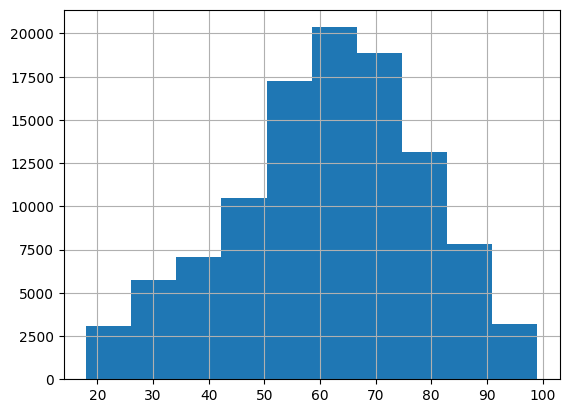

In [6]:
df["age"].hist()
# Divide age into bins: 0-50, 50-60, 60-70, 70-80, 80-90, 90+
bins = [0, 50, 60, 70, 80, 90, 100]
labels = ["0-50", "50-60", "60-70", "70-80", "80-90", "90+"]
df["age_bin"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)
df["age_bin"].value_counts()

In [7]:
# Remove unused columns
df = df.drop(columns=["event_id", "subject_id", "hadm_id", "date", "number_of_treatments_last_180_days", "days_with_treatment_last_180_days", "days_since_last_treatment", "age", "admission_days", "drugs"])

In [8]:
# Check type and values of each column
for c in df.columns:
    print("Column:", c)
    print("Type:", df[c].dtype)
    print("Number of unique values:", df[c].nunique())

Column: ab_name
Type: object
Number of unique values: 24
Column: spec_type_desc
Type: object
Number of unique values: 37
Column: interpretation
Type: object
Number of unique values: 5
Column: gender
Type: object
Number of unique values: 2
Column: admission_type
Type: object
Number of unique values: 9
Column: admission_location
Type: object
Number of unique values: 11
Column: exitus
Type: object
Number of unique values: 2
Column: discharge_location
Type: object
Number of unique values: 13
Column: race
Type: object
Number of unique values: 33
Column: language
Type: object
Number of unique values: 24
Column: icu_when_culture
Type: object
Number of unique values: 43
Column: treatment_last_180_days
Type: bool
Number of unique values: 2
Column: age_bin
Type: category
Number of unique values: 6


In [9]:
df.shape

(107012, 13)

In [10]:
df.interpretation.value_counts()

interpretation
S    80317
R    26527
I      164
N        3
D        1
Name: count, dtype: int64

In [12]:
# Group "I" "N" and "D" values of interpretation into "Other"
df["interpretation"] = df["interpretation"].replace({"I": "Other", "N": "Other", "D": "Other"})
df.interpretation.value_counts()

interpretation
S        80317
R        26527
Other      168
Name: count, dtype: int64

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["interpretation"])
df_tuning, df_val = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train["interpretation"])
df_train.to_csv("../mimic-iv-staph_train.csv", index=False)
df_test.to_csv("../mimic-iv-staph_test.csv", index=False)
df_tuning.to_csv("../mimic-iv-staph_tuning.csv", index=False)
df_val.to_csv("../mimic-iv-staph_validation.csv", index=False)


In [14]:
df.to_csv("../mimic-iv-staph.csv", index=False)